In [2]:
from src_PI.trotter_theory.trotter_theory import DynamicalPion_TrotterStep_Tgates_cost, get_Trotter_steps_cross_time
import matplotlib.pyplot as plt
import numpy as np
from src_PI.hamiltonians.core.EFTParameters import *
import matplotlib.pyplot as plt

In [3]:
L = 10
e = 0.1
A=40
E_bound = 10
E_kin = 10
nb, _, _ = calculate_dynamic_cutoffs(L, 3, A, get_physical_parameters(), epsilon_cut=0.1, E_bound=E_bound)
r = get_Trotter_steps_cross_time(L, A, E_bound, E_kin, e, Cp=1e-3)
a = DynamicalPion_TrotterStep_Tgates_cost(L, nb, e/(3*r))
print(a*r)

5.1973083177111626e+42


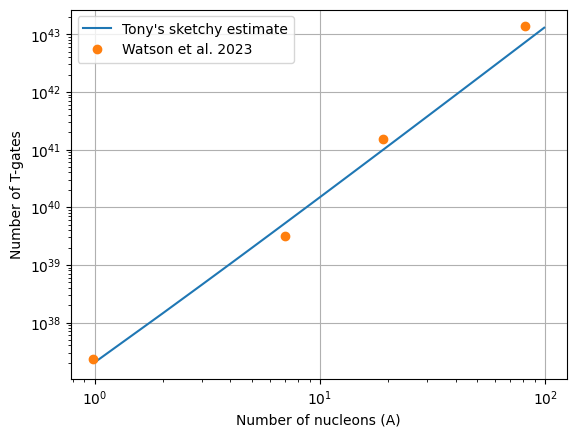

In [4]:
x = np.arange(1, 100, 1)
T1 = np.array([DynamicalPion_TrotterStep_Tgates_cost(L, 3, e/(3*r))*get_Trotter_steps_cross_time(L, A, 10*A, 10, e, Cp=1e-2) for A in x])
plt.loglog(x,T1, label="Tony's sketchy estimate")


x_data = 10**np.array([-0.006289308176100629, 0.8427672955974843, 1.279874213836478, 1.9119496855345912])
y_data = 10**np.array([37.37096774193549, 39.5, 41.185483870967744, 43.13709677419355])
plt.loglog(x_data, y_data, "o", label="Watson et al. 2023")
plt.xlabel("Number of nucleons (A)")
plt.ylabel("Number of T-gates")
plt.grid()
plt.legend()

In [5]:
def commutator_bound_WT_WT(L, A, E_bound):
    """Lemma 78 of Watson et. al 2025"""
    params = get_physical_parameters()
    f_pi = params['f_pi']
    a_L = params['a_L']
    _, pi_max, Pi_max = calculate_dynamic_cutoffs(L, 3, A, params, epsilon_cut=0.1, E_bound=E_bound)
    return 384 * (1/(4*f_pi**2))**2 *(3 * pi_max * Pi_max+ 2/(a_L**3)) * pi_max * Pi_max * A

In [6]:
A=40
L=10
commutator_bound_WT_WT(L, A, 10*A)

1.04724152110951e+26

In [8]:
f_pi = 93
384 * (1/(4*f_pi**2))**2


3.208333067643251e-07